In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/silver/base_silver.csv")

# Remove casos fora da metodologia principal
if "flag_fase_9" in df.columns:
    df = df[df["flag_fase_9"] == 0].copy()
#lembrete: fase 9 da base de 2024 divergente da metodologia aplicada no relatorio pede

# Ordenação temporal
df = df.sort_values(["id_aluno", "ano_ref"])

# df.head()




In [25]:
mapa_fase = {
    0: "Alfa",
    1: "Fase 1",
    2: "Fase 2",
    3: "Fase 3",
    4: "Fase 4",
    5: "Fase 5",
    6: "Fase 6",
    7: "Fase 7",
    8: "Fase 8"
}

df["fase_nome"] = df["fase"].map(mapa_fase)

# Criar deltas temporais:

df["delta_ida"] = df.groupby("id_aluno")["ida"].diff()
df["delta_ieg"] = df.groupby("id_aluno")["ieg"].diff()
df["delta_inde"] = df.groupby("id_aluno")["inde"].diff()
df["delta_ian"] = df.groupby("id_aluno")["ian"].diff()

df["queda_ida"] = (df["delta_ida"] < 0).astype(int)
df["queda_ieg"] = (df["delta_ieg"] < 0).astype(int)
df["queda_inde"] = (df["delta_inde"] < 0).astype(int)


In [26]:
df["ips_anterior"] = df.groupby("id_aluno")["ips"].shift(1)
df["ida_anterior"] = df.groupby("id_aluno")["ida"].shift(1)
df["ieg_anterior"] = df.groupby("id_aluno")["ieg"].shift(1)

In [27]:
def classificar_defasagem(valor):
    if pd.isna(valor):
        return "Sem informação"
    elif valor >= 1:
        return "Adiantado"
    elif valor == 0:
        return "Adequado"
    elif valor == -1:
        return "Defasagem leve"
    else:
        return "Defasagem moderada/severa"

df["perfil_defasagem"] = df["defasagem"].apply(classificar_defasagem)

ordem_defasagem = [
    "Defasagem moderada/severa",
    "Defasagem leve",
    "Adequado",
    "Adiantado"
]

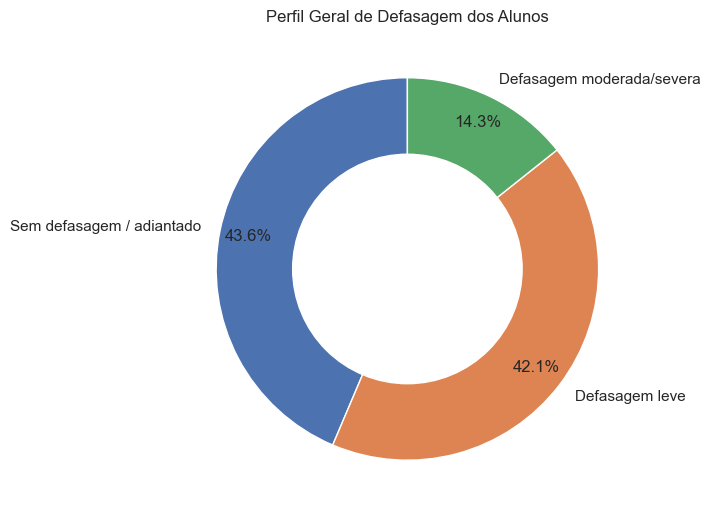

In [5]:
perfil_geral = (
    df["perfil_defasagem"]
    .value_counts()
    .reset_index()
)

perfil_geral.columns = ["perfil_defasagem", "qtd_alunos"]

plt.figure(figsize=(7, 7))

plt.pie(
    perfil_geral["qtd_alunos"],
    labels=perfil_geral["perfil_defasagem"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85
)

# círculo no meio para virar rosca
centro = plt.Circle((0, 0), 0.60, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centro)

plt.title("Perfil Geral de Defasagem dos Alunos")
plt.tight_layout()
plt.show()

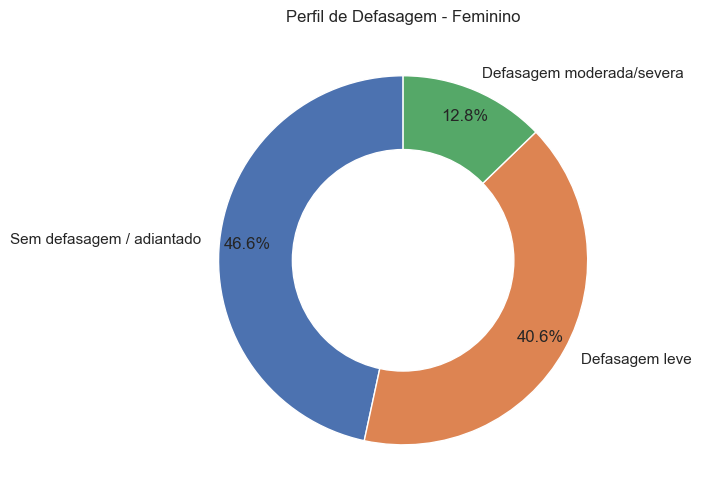

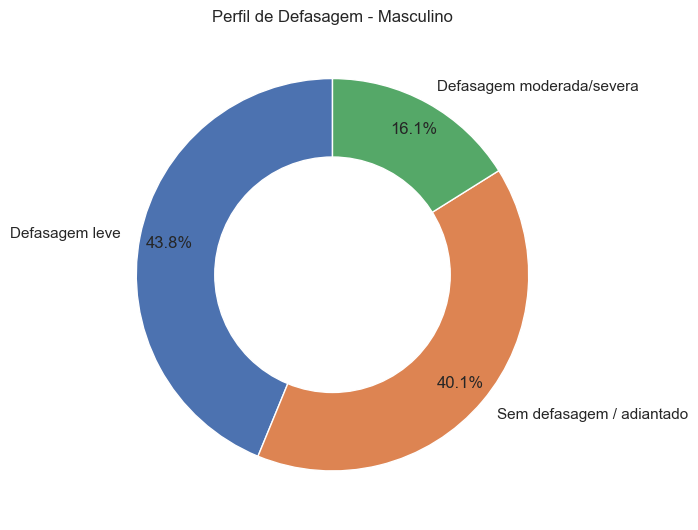

In [6]:
generos = df["genero"].dropna().unique()

for genero in generos:
    dados_genero = df[df["genero"] == genero]

    perfil_genero = (
        dados_genero["perfil_defasagem"]
        .value_counts()
        .reset_index()
    )

    perfil_genero.columns = ["perfil_defasagem", "qtd_alunos"]

    plt.figure(figsize=(7, 7))

    plt.pie(
        perfil_genero["qtd_alunos"],
        labels=perfil_genero["perfil_defasagem"],
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.85
    )

    centro = plt.Circle((0, 0), 0.60, fc="white")
    fig = plt.gcf()
    fig.gca().add_artist(centro)

    plt.title(f"Perfil de Defasagem - {genero}")
    plt.tight_layout()
    plt.show()

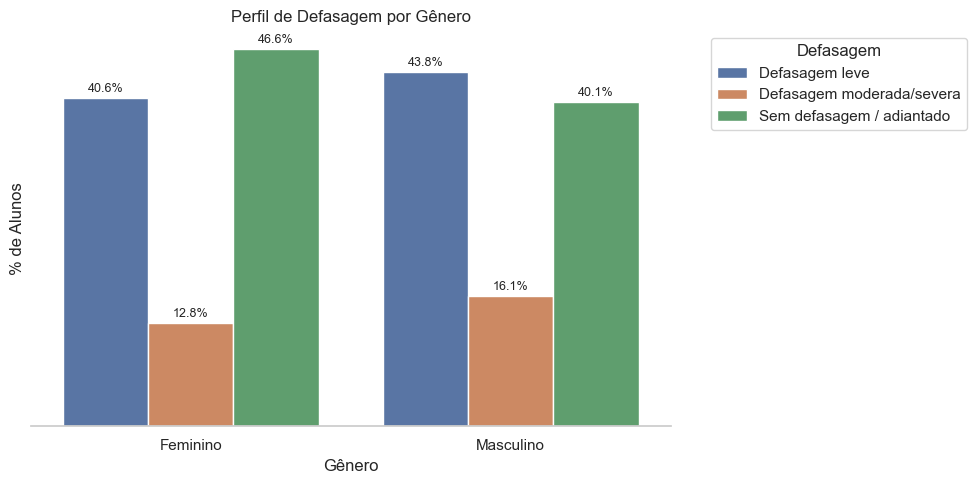

In [9]:
perfil_genero = (
    df.groupby(["genero", "perfil_defasagem"])
    .size()
    .reset_index(name="qtd_alunos")
)

perfil_genero["perc_alunos"] = (
    perfil_genero["qtd_alunos"] /
    perfil_genero.groupby("genero")["qtd_alunos"].transform("sum") * 100
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=perfil_genero,
    x="genero",
    y="perc_alunos",
    hue="perfil_defasagem"
)

plt.title("Perfil de Defasagem por Gênero")
plt.xlabel("Gênero")
plt.ylabel("% de Alunos")
plt.legend(title="Defasagem", bbox_to_anchor=(1.05, 1), loc="upper left")

# rótulos de dados
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="edge",
        fontsize=9,
        padding=2
    )

# remove grade
ax.grid(False)

# remove escala/eixo Y
# ax.set_ylabel("")
ax.set_yticks([])

# remove bordas do gráfico
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

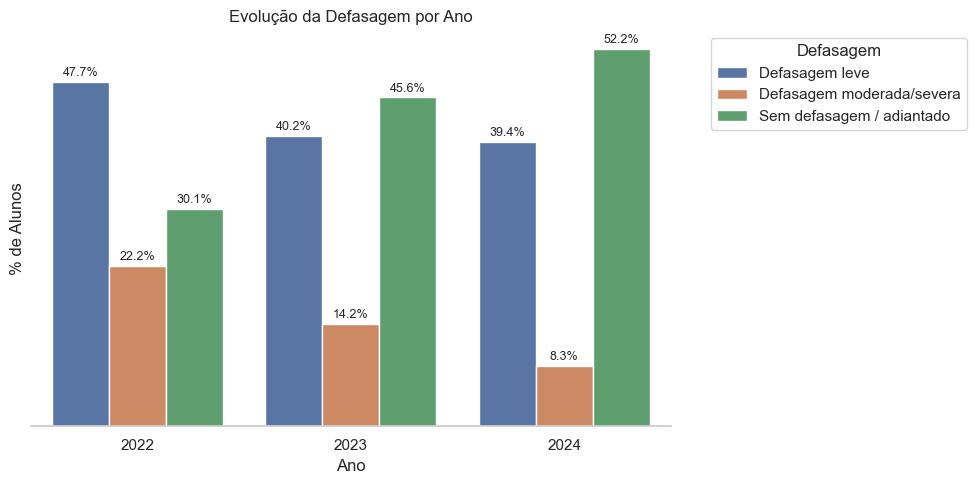

In [10]:
perfil_ano = (
    df.groupby(["ano_ref", "perfil_defasagem"])
    .size()
    .reset_index(name="qtd_alunos")
)

perfil_ano["perc_alunos"] = (
    perfil_ano["qtd_alunos"] /
    perfil_ano.groupby("ano_ref")["qtd_alunos"].transform("sum") * 100
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=perfil_ano,
    x="ano_ref",
    y="perc_alunos",
    hue="perfil_defasagem"
)

plt.title("Evolução da Defasagem por Ano")
plt.xlabel("Ano")
plt.ylabel("% de Alunos")
plt.legend(title="Defasagem", bbox_to_anchor=(1.05, 1), loc="upper left")

# rótulos de dados
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="edge",
        fontsize=9,
        padding=2
    )
# remove grade
ax.grid(False)

# remove escala/eixo Y
# ax.set_ylabel("")
ax.set_yticks([])

# remove bordas do gráfico
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

A variável gênero não foi incluída no modelo preditivo porque, na análise exploratória, não foram observadas diferenças relevantes entre os grupos quanto ao perfil de defasagem. Além disso, a remoção reduz o risco de enviesamento do modelo por características demográficas, mantendo o foco em indicadores acadêmicos, psicopedagógicos e de engajamento.

1. Adequação do nível — IAN
Perfil geral do IAN por ano

In [51]:
def classificar_defasagem_ian(ian):
    if pd.isna(ian):
        return "Sem informação"
    elif ian >= 7:
        return "Adequado/Baixa defasagem"
    elif ian >= 4:
        return "Defasagem moderada"
    else:
        return "Defasagem severa"

df["perfil_defasagem"] = df["ian"].apply(classificar_defasagem_ian)

ordem_defasagem = [
    "Adequado/Baixa defasagem",
    "Defasagem moderada",
    "Defasagem severa",
    "Sem informação"
]

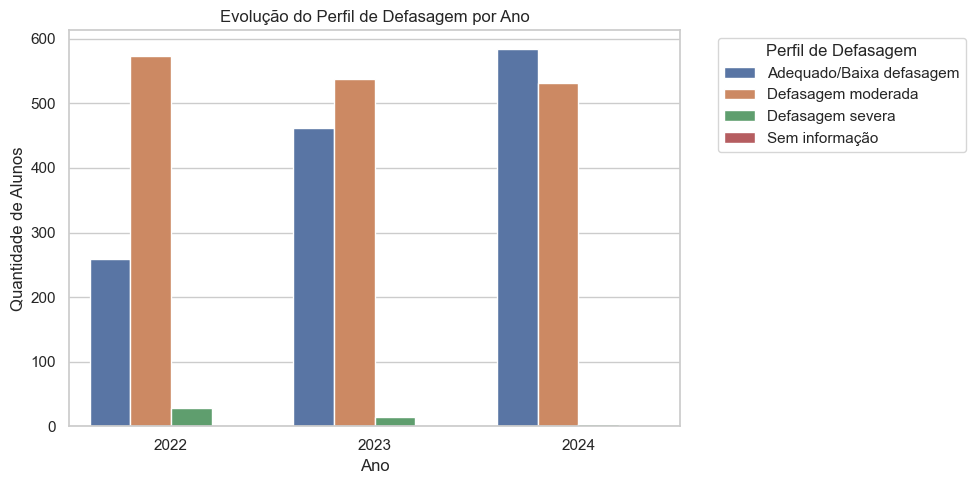

In [52]:
perfil_ano = (
    df.groupby(["ano_ref", "perfil_defasagem"])
    .size()
    .reset_index(name="qtd_alunos")
)

perfil_ano["perfil_defasagem"] = pd.Categorical(
    perfil_ano["perfil_defasagem"],
    categories=ordem_defasagem,
    ordered=True
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=perfil_ano,
    x="ano_ref",
    y="qtd_alunos",
    hue="perfil_defasagem",
    hue_order=ordem_defasagem
)

plt.title("Evolução do Perfil de Defasagem por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Alunos")
plt.legend(title="Perfil de Defasagem", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

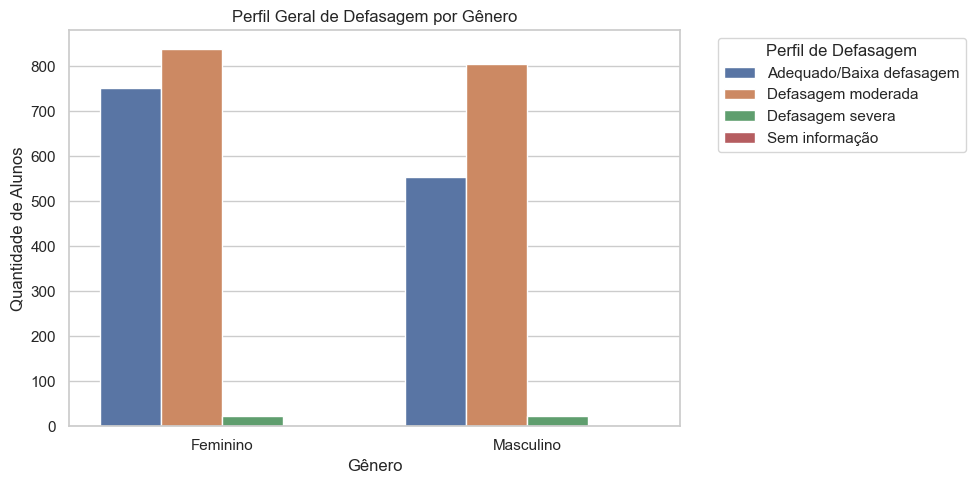

In [53]:
perfil_genero = (
    df.groupby(["genero", "perfil_defasagem"])
    .size()
    .reset_index(name="qtd_alunos")
)

perfil_genero["perfil_defasagem"] = pd.Categorical(
    perfil_genero["perfil_defasagem"],
    categories=ordem_defasagem,
    ordered=True
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=perfil_genero,
    x="genero",
    y="qtd_alunos",
    hue="perfil_defasagem",
    hue_order=ordem_defasagem
)

plt.title("Perfil Geral de Defasagem por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Quantidade de Alunos")
plt.legend(title="Perfil de Defasagem", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

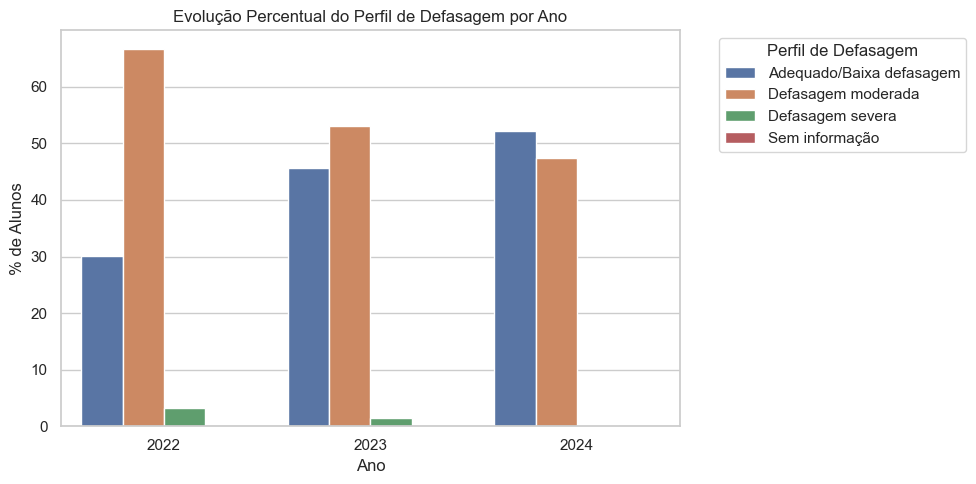

In [54]:
perfil_ano_pct = (
    df.groupby(["ano_ref", "perfil_defasagem"])
    .size()
    .reset_index(name="qtd_alunos")
)

perfil_ano_pct["perc_alunos"] = (
    perfil_ano_pct["qtd_alunos"] /
    perfil_ano_pct.groupby("ano_ref")["qtd_alunos"].transform("sum") * 100
)

perfil_ano_pct["perfil_defasagem"] = pd.Categorical(
    perfil_ano_pct["perfil_defasagem"],
    categories=ordem_defasagem,
    ordered=True
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=perfil_ano_pct,
    x="ano_ref",
    y="perc_alunos",
    hue="perfil_defasagem",
    hue_order=ordem_defasagem
)

plt.title("Evolução Percentual do Perfil de Defasagem por Ano")
plt.xlabel("Ano")
plt.ylabel("% de Alunos")
plt.legend(title="Perfil de Defasagem", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Média do IAN ao longo dos anos

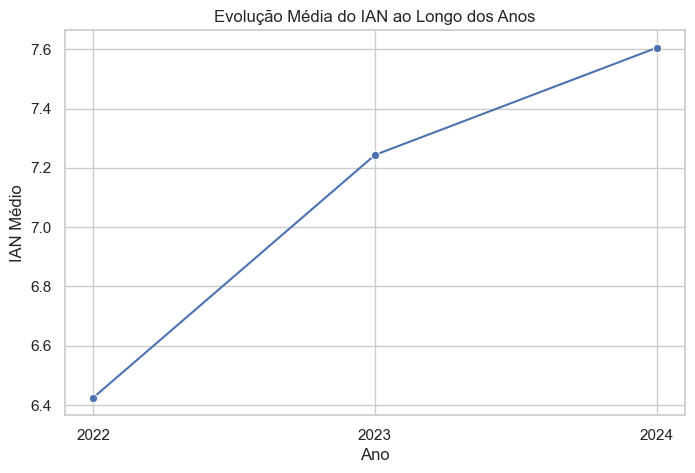

In [11]:

ian_ano = df.groupby("ano_ref")["ian"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=ian_ano,
    x="ano_ref",
    y="ian",
    marker="o"
)

plt.title("Evolução Média do IAN ao Longo dos Anos")
plt.xlabel("Ano")
plt.ylabel("IAN Médio")
plt.xticks([2022, 2023, 2024])
plt.show()




Perfil de defasagem

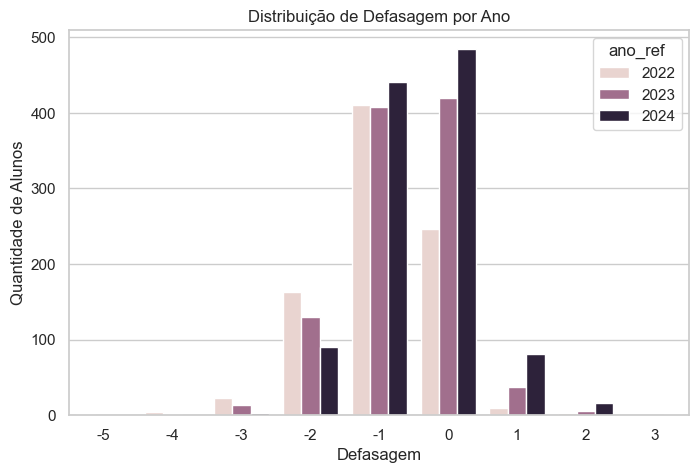

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="defasagem",
    hue="ano_ref"
)

plt.title("Distribuição de Defasagem por Ano")
plt.xlabel("Defasagem")
plt.ylabel("Quantidade de Alunos")
plt.show()


2. Desempenho acadêmico — 
IDA médio por ano

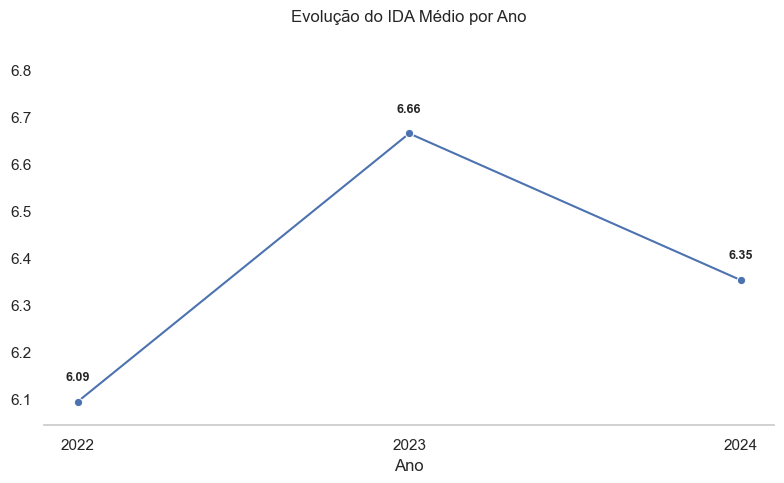

In [16]:
ida_ano = df.groupby("ano_ref")["ida"].mean().reset_index()

plt.figure(figsize=(8,5))

ax = sns.lineplot(
    data=ida_ano,
    x="ano_ref",
    y="ida",
    marker="o"
)

ax.set_title("Evolução do IDA Médio por Ano", pad=20)
ax.set_xlabel("Ano")
ax.set_ylabel("")
ax.set_xticks([2022, 2023, 2024])

# aumenta respiro no topo
y_min = ida_ano["ida"].min()
y_max = ida_ano["ida"].max()
ax.set_ylim(y_min - 0.05, y_max + 0.18)

# rótulos de dados
for _, row in ida_ano.iterrows():
    ax.text(
        row["ano_ref"],
        row["ida"] + 0.04,
        f'{row["ida"]:.2f}',
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# limpeza visual
ax.grid(False)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()


#MEDIA GERAL E MEDIA POR GENERO (GRAFICO DE LINHAS VERSUS COLUNA)

IDA médio por fase e ano

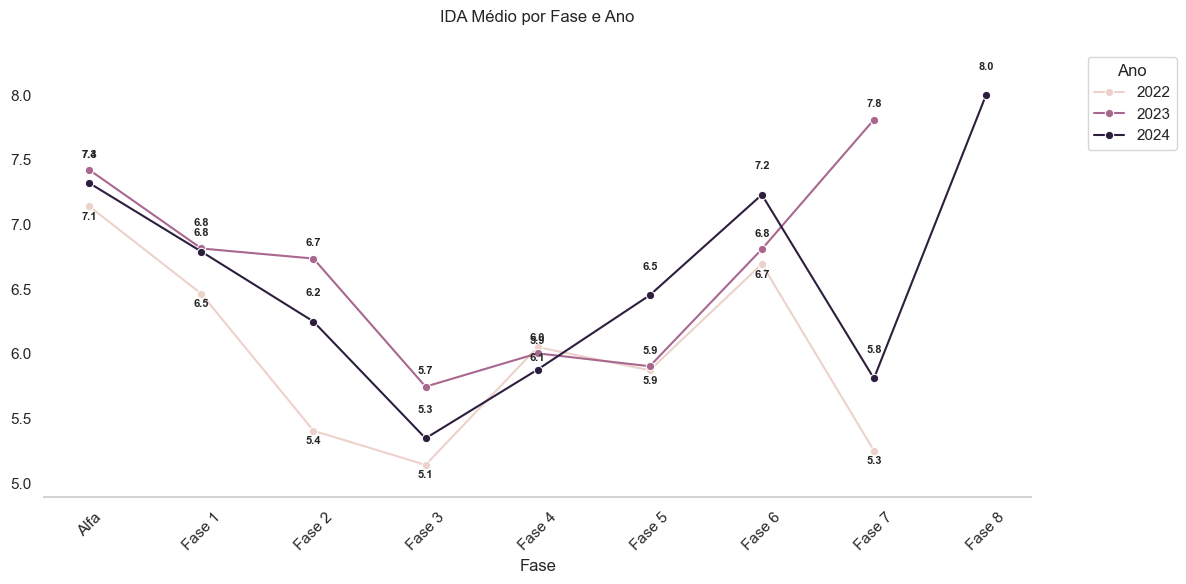

In [18]:
ida_fase_ano = (
    df.groupby(["ano_ref", "fase_nome"])["ida"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

ax = sns.lineplot(
    data=ida_fase_ano,
    x="fase_nome",
    y="ida",
    hue="ano_ref",
    marker="o"
)

ax.set_title("IDA Médio por Fase e Ano", pad=20)
ax.set_xlabel("Fase")
ax.set_ylabel("")
plt.xticks(rotation=45)

# aumenta respiro superior/inferior
y_min = ida_fase_ano["ida"].min()
y_max = ida_fase_ano["ida"].max()
ax.set_ylim(y_min - 0.25, y_max + 0.35)

# deslocamento dos rótulos por ano
offsets = {
    2022: -0.12,
    2023:  0.08,
    2024:  0.18
}

for _, row in ida_fase_ano.iterrows():
    ax.text(
        row["fase_nome"],
        row["ida"] + offsets.get(row["ano_ref"], 0.08),
        f'{row["ida"]:.1f}',
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

# limpeza visual
ax.grid(False)
# ax.set_yticks([])
sns.despine(left=True, bottom=False)

plt.legend(title="Ano", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

3. Engajamento — IEG vs IDA/IPV
Correlação entre IEG, IDA e IPV

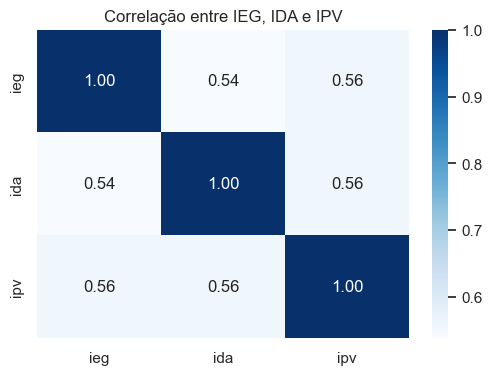

In [13]:
corr_ieg = df[["ieg", "ida", "ipv"]].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_ieg,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlação entre IEG, IDA e IPV")
plt.show()

IEG vs IDA

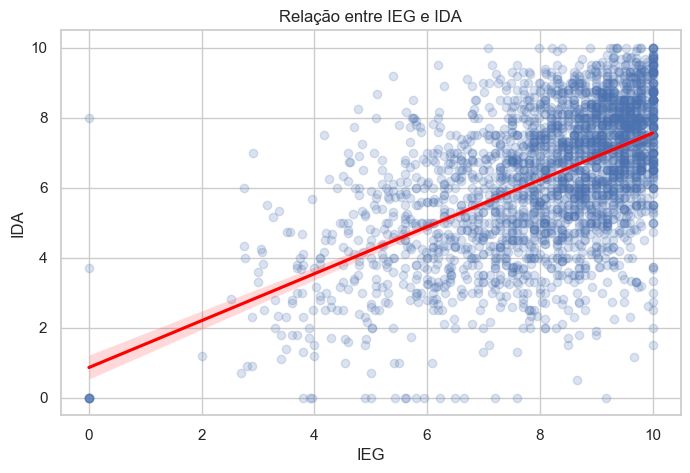

In [19]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="ieg",
    y="ida",
    scatter_kws={"alpha":0.20},
    line_kws={"color":"red"}
)

plt.title("Relação entre IEG e IDA")
plt.xlabel("IEG")
plt.ylabel("IDA")

plt.show()

#TROCAR GRAFICO OU NAO, PORQUE OS PONTOS CONCENTRANSE MAIS NO CANTO SUPERIOR DIREITO

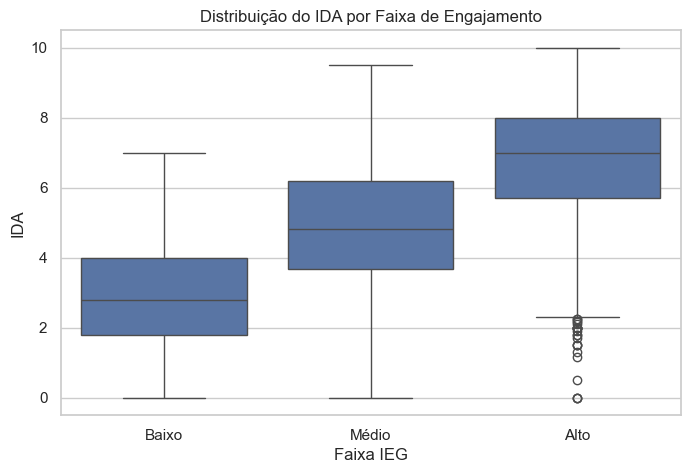

In [20]:
df["faixa_ieg"] = pd.cut(
    df["ieg"],
    bins=[0,4,7,10],
    labels=["Baixo","Médio","Alto"]
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="faixa_ieg",
    y="ida"
)

plt.title("Distribuição do IDA por Faixa de Engajamento")
plt.xlabel("Faixa IEG")
plt.ylabel("IDA")

plt.show()

IEG vs IPV

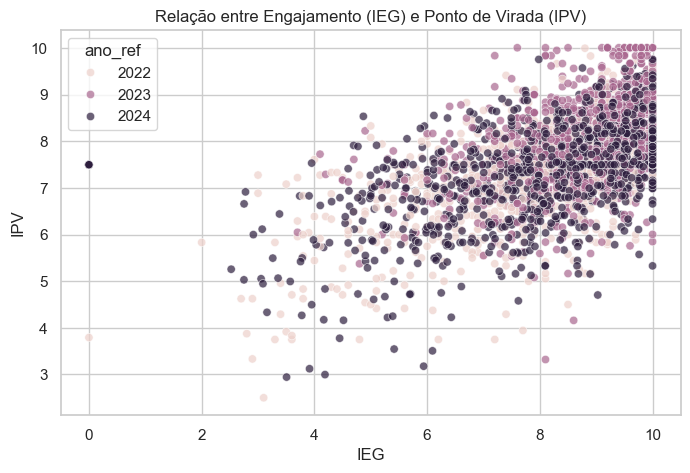

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="ieg",
    y="ipv",
    hue="ano_ref",
    alpha=0.7
)

plt.title("Relação entre Engajamento (IEG) e Ponto de Virada (IPV)")
plt.xlabel("IEG")
plt.ylabel("IPV")
plt.show()

4. Autoavaliação — IAA vs IDA/IEG
Correlação IAA, IDA e IEG

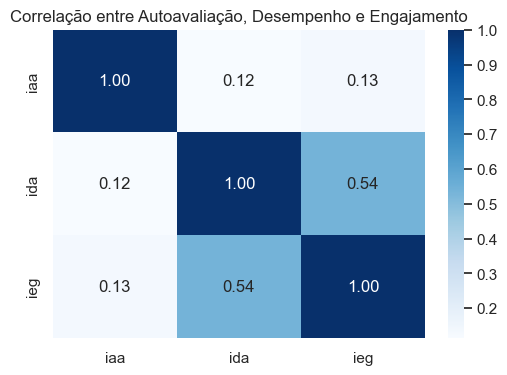

In [17]:
corr_iaa = df[["iaa", "ida", "ieg"]].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_iaa,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlação entre Autoavaliação, Desempenho e Engajamento")
plt.show()

#TROCAR O GRAFICO

IAA vs IDA

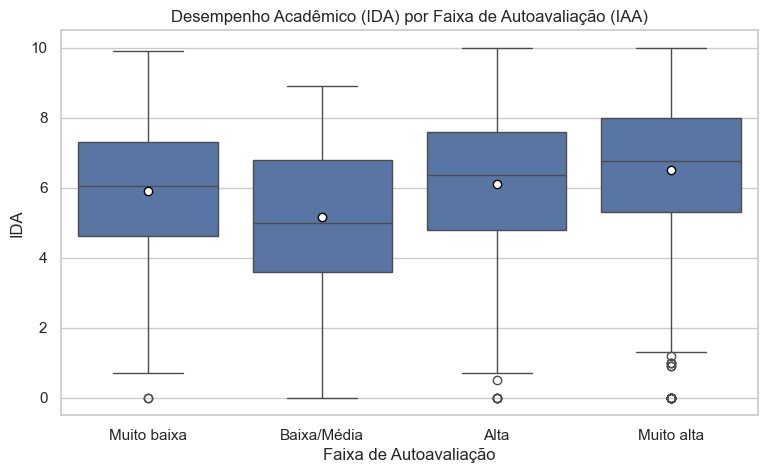

In [46]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_iaa,
    x="faixa_iaa",
    y="ida",
    showmeans=True,
    meanprops={
        "marker":"o",
        "markerfacecolor":"white",
        "markeredgecolor":"black"
    }
)

plt.title("Desempenho Acadêmico (IDA) por Faixa de Autoavaliação (IAA)")
plt.xlabel("Faixa de Autoavaliação")
plt.ylabel("IDA")

plt.show()

Observou-se relação positiva entre autoavaliação (IAA) e desempenho acadêmico (IDA), indicando que estudantes com maior percepção de desempenho tendem, em média, a apresentar melhores resultados acadêmicos.

Entretanto, a relação não é perfeitamente linear. Foram identificados alunos com autoavaliação elevada e desempenho mediano ou baixo, sugerindo possível desalinhamento entre percepção individual e resultado acadêmico efetivo.

Também foi identificado comportamento atípico no ano de 2023, com aproximadamente 20% dos registros apresentando IAA igual a zero, indicando possível diferença metodológica ou inconsistência de preenchimento entre os anos.

média de IDA por faixa de IAA e ano

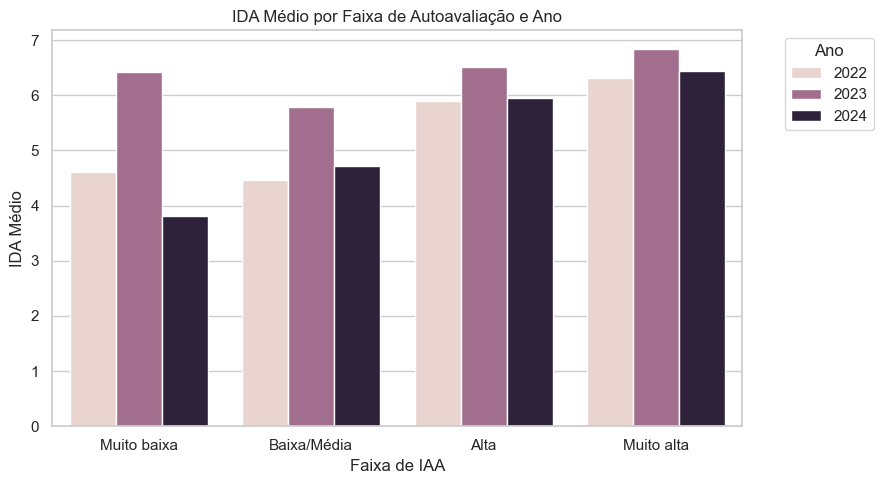

In [42]:
media_iaa = (
    df_iaa
    .groupby(["ano_ref", "faixa_iaa"], observed=True)["ida"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9,5))

sns.barplot(
    data=media_iaa,
    x="faixa_iaa",
    y="ida",
    hue="ano_ref"
)

plt.title("IDA Médio por Faixa de Autoavaliação e Ano")
plt.xlabel("Faixa de IAA")
plt.ylabel("IDA Médio")

plt.legend(
    title="Ano",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [43]:
df["iaa"].value_counts(dropna=False).sort_index()

iaa
0.000     249
1.700       1
3.498       1
3.500       2
4.000       1
         ... 
9.585      59
9.600      57
10.000    201
10.002    122
NaN       127
Name: count, Length: 71, dtype: int64

In [44]:
pd.crosstab(df["ano_ref"], df["iaa"], normalize="index") * 100

iaa,0.000,1.700,3.498,3.500,4.000,4.100,4.584,4.600,4.700,5.000,...,9.000,9.002,9.168,9.200,9.500,9.502,9.585,9.600,10.000,10.002
ano_ref,,,,,,,,,,,,,,,,,,,,,
2022,4.534884,0.000000,0.000000,0.232558,0.000000,0.000000,0.000000,0.116279,0.000000,0.116279,...,13.837209,0.000000,0.000000,5.000000,14.302326,0.000000,0.000000,2.441860,12.674419,0.000000
2023,19.978970,0.105152,0.000000,0.000000,0.105152,0.105152,0.000000,0.105152,0.315457,0.105152,...,11.882229,0.000000,0.000000,4.311251,10.830705,0.000000,0.000000,3.785489,9.674027,0.000000
2024,1.897533,0.000000,0.094877,0.000000,0.000000,0.000000,0.094877,0.000000,0.000000,0.000000,...,0.000000,11.290323,8.633776,0.000000,0.000000,10.341556,5.597723,0.000000,0.000000,11.574953


In [45]:
df.groupby("ano_ref")["iaa"].apply(lambda x: (x == 0).mean() * 100)

ano_ref
2022     4.534884
2023    18.737673
2024     1.788909
Name: iaa, dtype: float64

IAA vs IEG

5. Aspectos psicossociais — IPS antes de quedas
IPS médio entre alunos com e sem queda de IDA

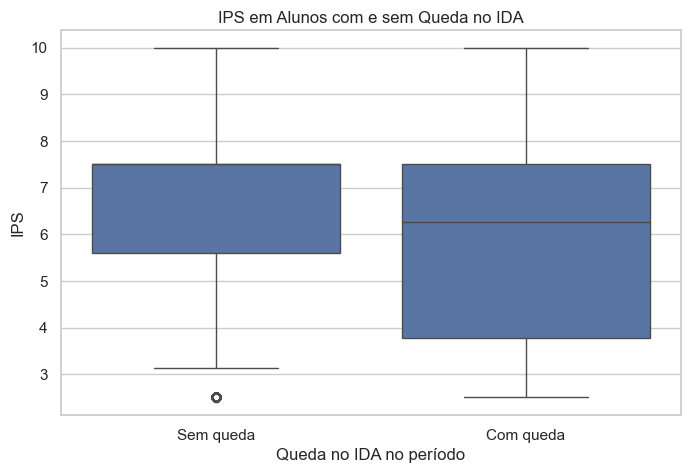

In [20]:
df_ips_queda = df.dropna(subset=["ips", "queda_ida"])

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_ips_queda,
    x="queda_ida",
    y="ips"
)

plt.title("IPS em Alunos com e sem Queda no IDA")
plt.xlabel("Queda no IDA no período")
plt.ylabel("IPS")
plt.xticks([0,1], ["Sem queda", "Com queda"])
plt.show()

IPS médio entre alunos com e sem queda de IEG

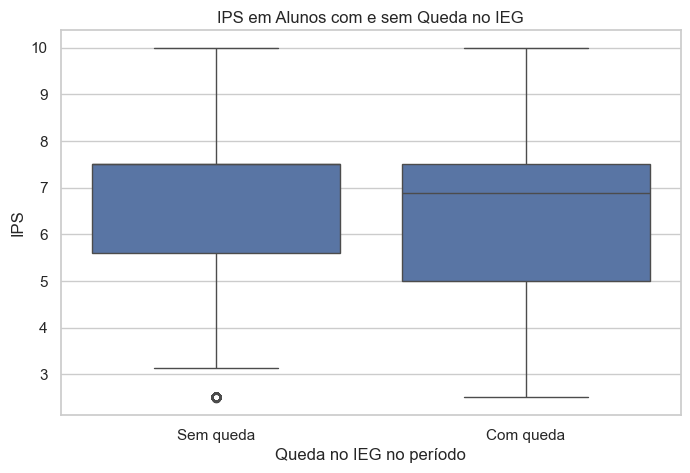

In [21]:
df_ips_ieg = df.dropna(subset=["ips", "queda_ieg"])

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_ips_ieg,
    x="queda_ieg",
    y="ips"
)

plt.title("IPS em Alunos com e sem Queda no IEG")
plt.xlabel("Queda no IEG no período")
plt.ylabel("IPS")
plt.xticks([0,1], ["Sem queda", "Com queda"])
plt.show()

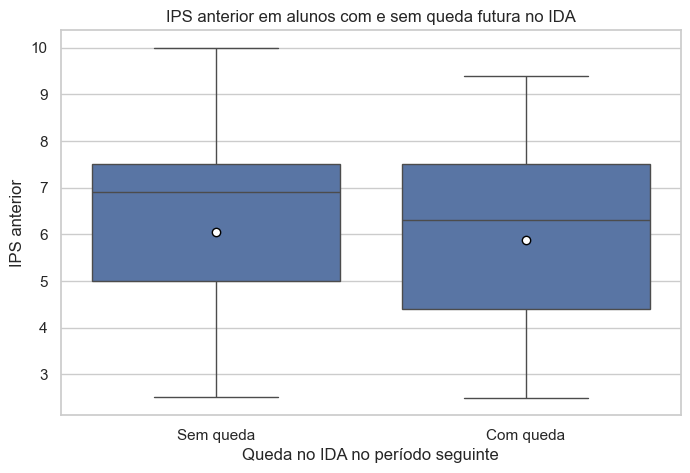

In [22]:
df_ips_queda_ida = df.dropna(subset=["ips_anterior", "queda_ida"])

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_ips_queda_ida,
    x="queda_ida",
    y="ips_anterior",
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black"
    }
)

plt.title("IPS anterior em alunos com e sem queda futura no IDA")
plt.xlabel("Queda no IDA no período seguinte")
plt.ylabel("IPS anterior")
plt.xticks([0,1], ["Sem queda", "Com queda"])

plt.show()

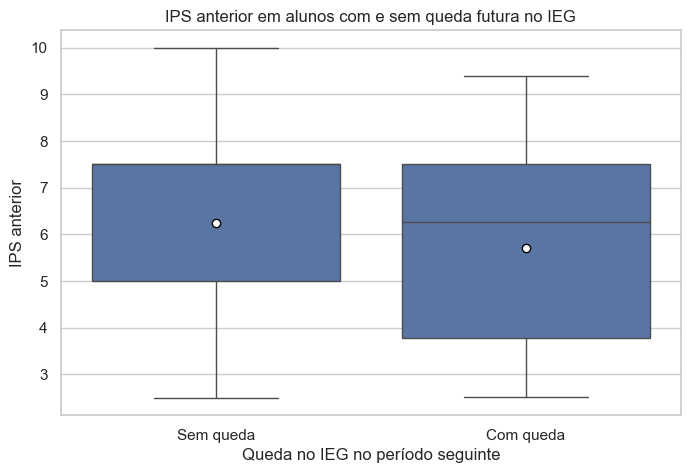

In [23]:
df_ips_queda_ieg = df.dropna(subset=["ips_anterior", "queda_ieg"])

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_ips_queda_ieg,
    x="queda_ieg",
    y="ips_anterior",
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black"
    }
)

plt.title("IPS anterior em alunos com e sem queda futura no IEG")
plt.xlabel("Queda no IEG no período seguinte")
plt.ylabel("IPS anterior")
plt.xticks([0,1], ["Sem queda", "Com queda"])

plt.show()

6. Aspectos psicopedagógicos — IPP vs IAN/Defasagem
Correlação entre IPP e IAN

IPP por nível de defasagem

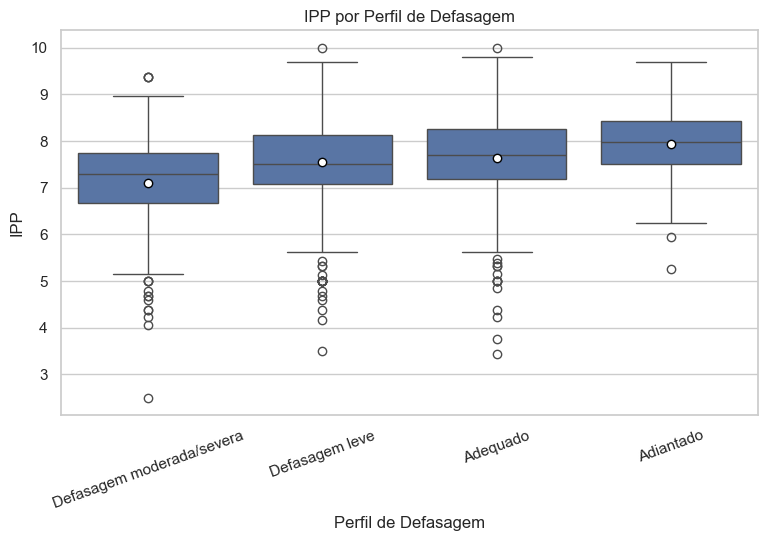

In [28]:
df_ipp = df.dropna(subset=["ipp", "perfil_defasagem"])

plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_ipp,
    x="perfil_defasagem",
    y="ipp",
    order=ordem_defasagem,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black"
    }
)

plt.title("IPP por Perfil de Defasagem")
plt.xlabel("Perfil de Defasagem")
plt.ylabel("IPP")
plt.xticks(rotation=20)

plt.show()

In [29]:
df_corr_ipp = df.dropna(subset=["ipp", "defasagem"])

corr_spearman = df_corr_ipp[["ipp", "defasagem"]].corr(method="spearman")
corr_pearson = df_corr_ipp[["ipp", "defasagem"]].corr(method="pearson")

print("Spearman:")
print(corr_spearman)

print("Pearson:")
print(corr_pearson)

Spearman:
                ipp  defasagem
ipp        1.000000   0.174908
defasagem  0.174908   1.000000
Pearson:
                ipp  defasagem
ipp        1.000000   0.181868
defasagem  0.181868   1.000000


7. Ponto de virada — IPV
Correlação de IPV com demais indicadores

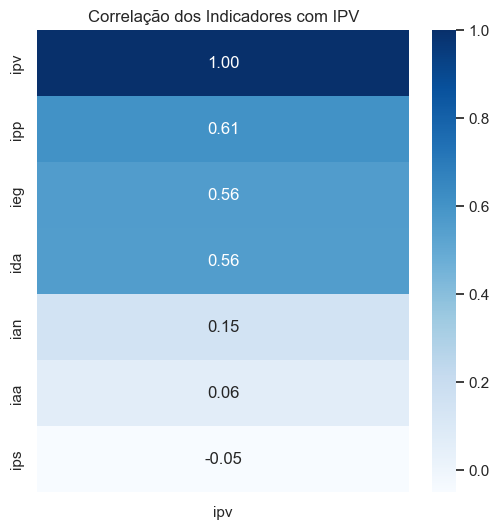

In [30]:
cols_ipv = ["ipv", "ida", "ieg", "iaa", "ips", "ipp", "ian"]

corr_ipv = (
    df[cols_ipv]
    .corr()[["ipv"]]
    .sort_values("ipv", ascending=False)
)

plt.figure(figsize=(6,6))

sns.heatmap(
    corr_ipv,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlação dos Indicadores com IPV")
plt.show()

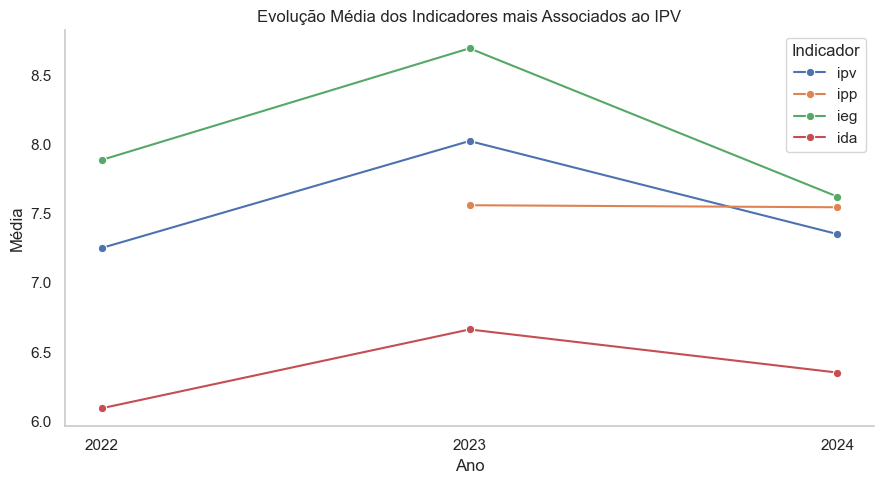

In [31]:
indicadores_tempo = (
    df.groupby("ano_ref")[["ipv", "ipp", "ieg", "ida"]]
    .mean()
    .reset_index()
)

indicadores_tempo_melt = indicadores_tempo.melt(
    id_vars="ano_ref",
    value_vars=["ipv", "ipp", "ieg", "ida"],
    var_name="indicador",
    value_name="media"
)

plt.figure(figsize=(9,5))

ax = sns.lineplot(
    data=indicadores_tempo_melt,
    x="ano_ref",
    y="media",
    hue="indicador",
    marker="o"
)

plt.title("Evolução Média dos Indicadores mais Associados ao IPV")
plt.xlabel("Ano")
plt.ylabel("Média")
plt.xticks([2022, 2023, 2024])

ax.grid(False)
sns.despine(left=False, bottom=False)

plt.legend(title="Indicador")
plt.tight_layout()
plt.show()

Evolução do IPV por ano

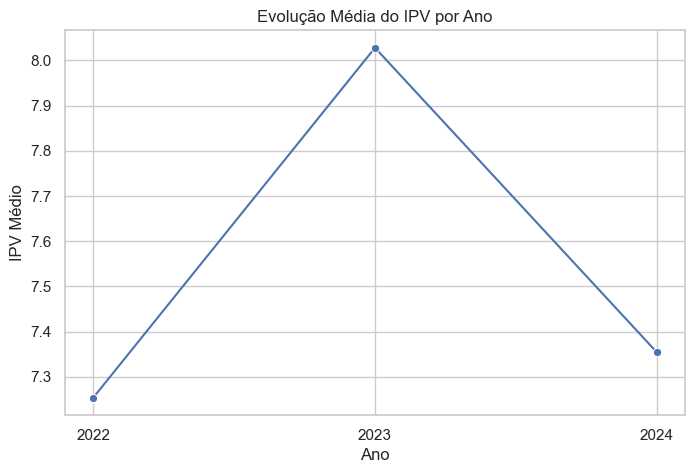

In [37]:
ipv_ano = df.groupby("ano_ref")["ipv"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=ipv_ano,
    x="ano_ref",
    y="ipv",
    marker="o"
)

plt.title("Evolução Média do IPV por Ano")
plt.xlabel("Ano")
plt.ylabel("IPV Médio")
plt.xticks([2022, 2023, 2024])
plt.show()


8. Multidimensionalidade — combinação de indicadores e INDE
Correlação geral com INDE

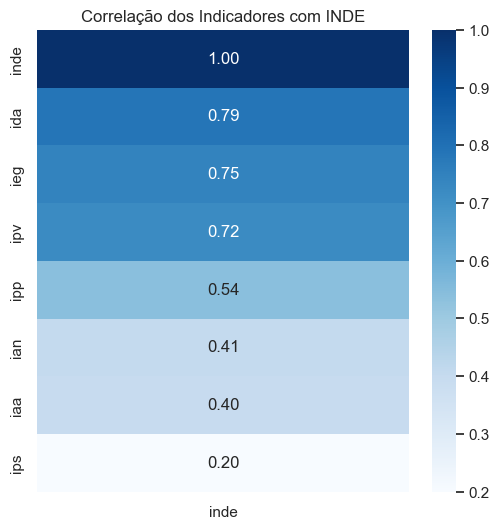

In [27]:
cols_inde = ["inde", "ida", "ieg", "ips", "ipp", "ipv", "iaa", "ian"]

corr_inde = df[cols_inde].corr()[["inde"]].sort_values("inde", ascending=False)

plt.figure(figsize=(6,6))

sns.heatmap(
    corr_inde,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlação dos Indicadores com INDE")
plt.show()

Heatmap IDA + IEG versus INDE

C:\Users\andre\AppData\Local\Temp\ipykernel_3004\2365574960.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heat_inde = df.pivot_table(


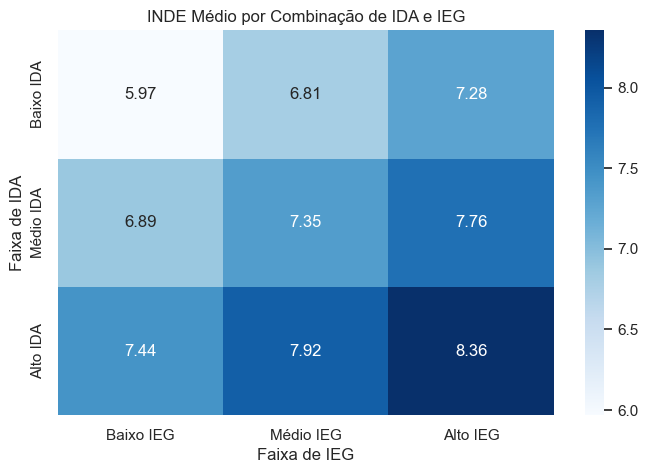

In [28]:
df["faixa_ida"] = pd.qcut(df["ida"], q=3, labels=["Baixo IDA", "Médio IDA", "Alto IDA"], duplicates="drop")
df["faixa_ieg"] = pd.qcut(df["ieg"], q=3, labels=["Baixo IEG", "Médio IEG", "Alto IEG"], duplicates="drop")

heat_inde = df.pivot_table(
    index="faixa_ida",
    columns="faixa_ieg",
    values="inde",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))

sns.heatmap(
    heat_inde,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("INDE Médio por Combinação de IDA e IEG")
plt.xlabel("Faixa de IEG")
plt.ylabel("Faixa de IDA")
plt.show()


Heatmap IPS + IPP versus INDE

C:\Users\andre\AppData\Local\Temp\ipykernel_3004\3890335025.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heat_inde_2 = df.pivot_table(


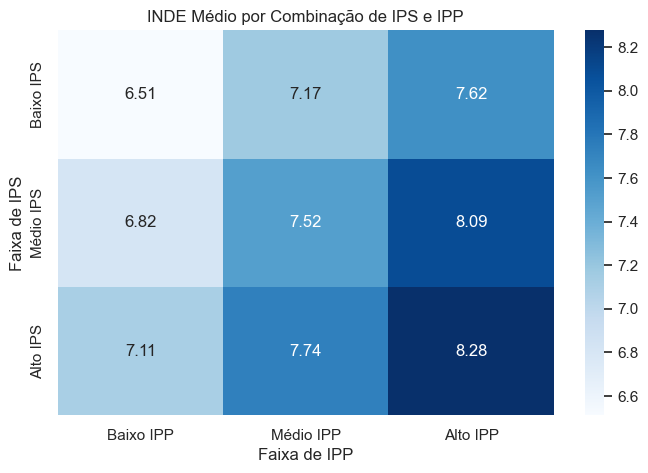

In [29]:
df["faixa_ips"] = pd.qcut(df["ips"], q=3, labels=["Baixo IPS", "Médio IPS", "Alto IPS"], duplicates="drop")
df["faixa_ipp"] = pd.qcut(df["ipp"], q=3, labels=["Baixo IPP", "Médio IPP", "Alto IPP"], duplicates="drop")

heat_inde_2 = df.pivot_table(
    index="faixa_ips",
    columns="faixa_ipp",
    values="inde",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))

sns.heatmap(
    heat_inde_2,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("INDE Médio por Combinação de IPS e IPP")
plt.xlabel("Faixa de IPP")
plt.ylabel("Faixa de IPS")
plt.show()


9. Previsão de risco com Machine Learning — análise exploratória do risco

In [30]:
df["risco_defasagem"] = (
    (df["ian"] < df["ian"].quantile(0.25)) |
    (df["queda_ida"] == 1) |
    (df["queda_ieg"] == 1)
).astype(int)


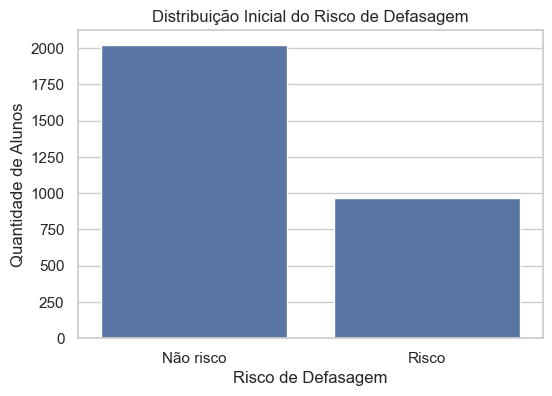

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="risco_defasagem"
)

plt.title("Distribuição Inicial do Risco de Defasagem")
plt.xlabel("Risco de Defasagem")
plt.ylabel("Quantidade de Alunos")
plt.xticks([0,1], ["Não risco", "Risco"])
plt.show()


Indicadores médios por risco

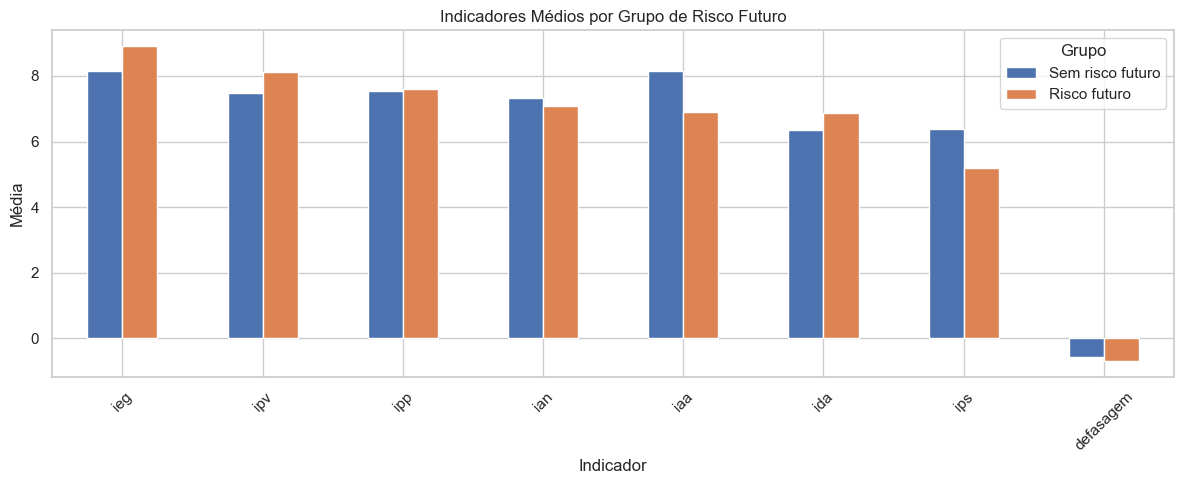

In [36]:

# variação futura
df["delta_ida_futuro"] = df.groupby("id_aluno")["ida"].shift(-1) - df["ida"]
df["delta_ieg_futuro"] = df.groupby("id_aluno")["ieg"].shift(-1) - df["ieg"]
df["delta_defasagem_futuro"] = df.groupby("id_aluno")["defasagem"].shift(-1) - df["defasagem"]

df["risco_defasagem_futuro"] = (
    (df["delta_ida_futuro"] < 0) |
    (df["delta_ieg_futuro"] < 0) |
    (df["delta_defasagem_futuro"] < 0)
).astype(int)

df_modelo = df.dropna(subset=[
    "risco_defasagem_futuro",
    "ida", "ieg", "ips", "ipp", "ipv", "ian", "inde"
])

features = ["ida", "ieg", "ips", "ipp", "ipv", "ian", "iaa", "defasagem"]

target = "risco_defasagem_futuro"

df_modelo = df.dropna(subset=features + [target])


indicadores_risco = (
    df_modelo
    .groupby("risco_defasagem_futuro")[features]
    .mean()
    .T
)

# renomear colunas para facilitar leitura
indicadores_risco.columns = ["Sem risco futuro", "Risco futuro"]

# ordenar da maior média do grupo de risco para a menor
indicadores_risco = indicadores_risco.sort_values(
    by="Risco futuro",
    ascending=False
)

ax = indicadores_risco.plot(kind="bar", figsize=(12,5))

plt.title("Indicadores Médios por Grupo de Risco Futuro")
plt.xlabel("Indicador")
plt.ylabel("Média")
plt.xticks(rotation=45)
plt.legend(title="Grupo")

plt.tight_layout()
plt.show()

In [38]:
# coeficientes = pd.DataFrame({
#     "variavel": features,
#     "coeficiente": modelo.named_steps["logreg"].coef_[0]
# }).sort_values("coeficiente", ascending=False)

# plt.figure(figsize=(8,5))

# sns.barplot(
#     data=coeficientes,
#     x="coeficiente",
#     y="variavel"
# )

# plt.title("Peso dos Indicadores na Previsão de Risco Futuro")
# plt.xlabel("Coeficiente do modelo")
# plt.ylabel("Indicador")
# plt.axvline(0, color="black", linewidth=1)

# plt.tight_layout()
# plt.show()


# print(classification_report(y_test, y_pred))
# print("AUC:", roc_auc_score(y_test, y_proba))

10. Efetividade do programa — Pedra/Fase/INDE
INDE médio por ano

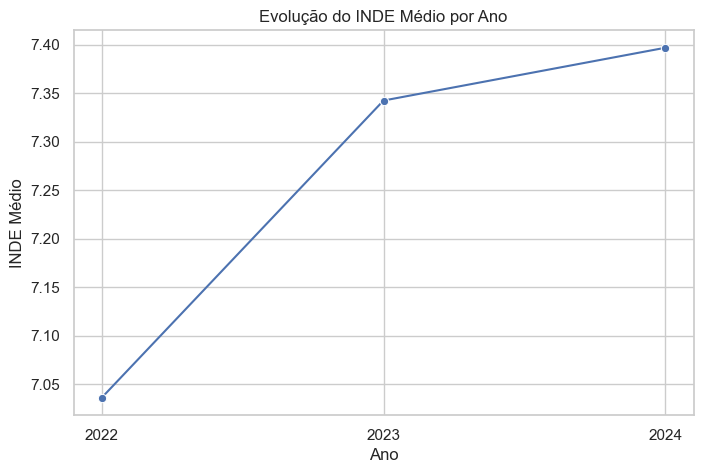

In [40]:
inde_ano = df.groupby("ano_ref")["inde"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=inde_ano,
    x="ano_ref",
    y="inde",
    marker="o"
)

plt.title("Evolução do INDE Médio por Ano")
plt.xlabel("Ano")
plt.ylabel("INDE Médio")
plt.xticks([2022, 2023, 2024])
plt.show()


Distribuição das pedras por ano

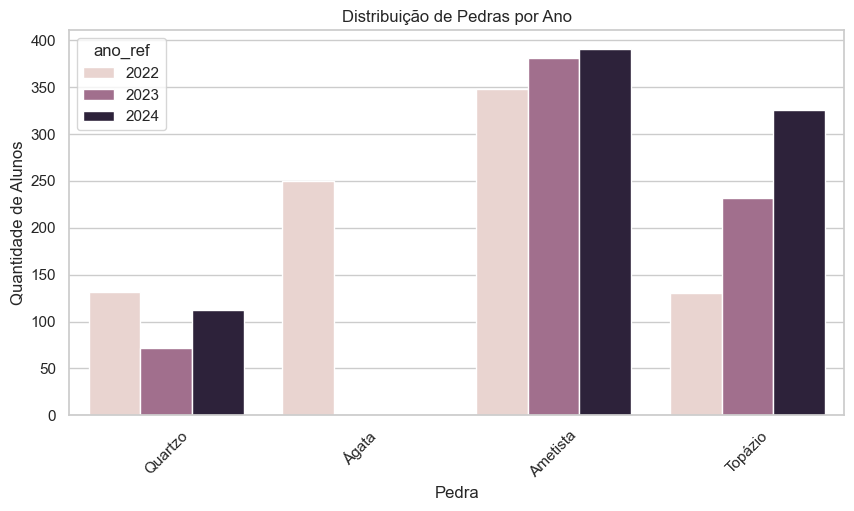

In [34]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="pedra",
    hue="ano_ref",
    order=["Quartzo", "Ágata", "Ametista", "Topázio"]
)

plt.title("Distribuição de Pedras por Ano")
plt.xlabel("Pedra")
plt.ylabel("Quantidade de Alunos")
plt.xticks(rotation=45)
plt.show()


In [39]:
df = df.sort_values(["id_aluno", "ano_ref"])

df["tem_futuro"] = df.groupby("id_aluno")["ano_ref"].shift(-1).notna()

df["delta_ida_futuro"] = df.groupby("id_aluno")["ida"].shift(-1) - df["ida"]
df["delta_ieg_futuro"] = df.groupby("id_aluno")["ieg"].shift(-1) - df["ieg"]
df["delta_defasagem_futuro"] = df.groupby("id_aluno")["defasagem"].shift(-1) - df["defasagem"]

df["risco_defasagem_futuro"] = (
    (df["delta_ida_futuro"] < 0) |
    (df["delta_ieg_futuro"] < 0) |
    (df["delta_defasagem_futuro"] < 0)
)

df.loc[~df["tem_futuro"], "risco_defasagem_futuro"] = pd.NA
df["risco_defasagem_futuro"] = df["risco_defasagem_futuro"].astype("Int64")

Path("../data/gold").mkdir(parents=True, exist_ok=True)
df.to_csv("../data/gold/base_gold_analitica.csv", index=False)

print(df.shape)
print(df.columns.tolist())

Base gold analítica salva com sucesso.
(2992, 47)
['id_aluno', 'ano_ref', 'fase', 'fase_original', 'flag_fase_9', 'idade', 'idade_original', 'flag_idade_padronizada', 'genero_original', 'genero', 'ano_ingresso', 'instituicao_original', 'instituicao_tipo', 'instituicao_subtipo', 'flag_bolsa_parceria', 'pedra', 'inde', 'iaa', 'ieg', 'ips', 'ipp', 'ida', 'ipv', 'ian', 'fase_ideal', 'defasagem', 'matematica', 'portugues', 'ingles', 'flag_sem_avaliacao', 'fase_nome', 'delta_ida', 'delta_ieg', 'delta_inde', 'delta_ian', 'queda_ida', 'queda_ieg', 'queda_inde', 'ips_anterior', 'ida_anterior', 'ieg_anterior', 'perfil_defasagem', 'delta_ida_futuro', 'delta_ieg_futuro', 'delta_defasagem_futuro', 'risco_defasagem_futuro', 'tem_futuro']


C:\Users\andre\AppData\Local\Temp\ipykernel_6084\1110994024.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[~df["tem_futuro"], "risco_defasagem_futuro"] = pd.NA
